# Affordance head training — SAM3D SLAT features + verb embedding

Trains `AffordanceMLP` on preprocessed SAM3D manifests.  
Input per vertex: `concat(slat_vertex (8,), verb_embedding (512,))` → affordance logit.

**Prerequisites:**
- Preprocessing done: `scripts/preprocess_affordsplat_sam3d.py` has written manifests under `data/manifests/`
- CLIP available for verb embeddings (`transformers` / `open_clip`)

**Workflow:**
1. Configure paths and hyperparameters in cell 2
2. Run all cells — training saves checkpoints to `CHECKPOINT_DIR`
3. Re-run cell 5 to resume from the latest checkpoint

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd().resolve()
for ROOT in [_cwd, *_cwd.parents]:
    if (ROOT / "pyproject.toml").is_file() and (ROOT / "src").is_dir():
        if str(ROOT / "src") not in sys.path:
            sys.path.insert(0, str(ROOT / "src"))
        break
else:
    raise RuntimeError("Run from the repo or notebooks/.")

from utils.config import load_config
cfg = load_config()
print("ROOT:", ROOT)

ROOT: /workspace


In [ ]:
import torch

# ── Manifests ────────────────────────────────────────────────────────────────
TRAIN_MANIFEST = ROOT / "data" / "manifests" / "train_sam3d.jsonl"
VAL_MANIFEST   = ROOT / "data" / "manifests" / "val_sam3d.jsonl"   # set to None to skip val

# ── Checkpointing ─────────────────────────────────────────────────────────────
CHECKPOINT_DIR = ROOT / "outputs" / "affordance_mlp"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
N_EPOCHS    = int(cfg.get("training", {}).get("num_epochs", 50))
LR          = float(cfg.get("training", {}).get("learning_rate", 1e-3))
LR_STEP     = 10    # decay LR by LR_GAMMA every LR_STEP epochs
LR_GAMMA    = 0.5
POS_WEIGHT  = float(cfg.get("training", {}).get("pos_weight", 5.0))
MAX_SAMPLES = None  # None = full dataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}  |  epochs: {N_EPOCHS}  |  lr: {LR}  |  pos_weight: {POS_WEIGHT}  |  max_samples: {MAX_SAMPLES}")
print(f"train manifest : {TRAIN_MANIFEST}")
print(f"val manifest   : {VAL_MANIFEST}")

/opt/conda/envs/sam3d/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


device: cuda  |  epochs: 50  |  lr: 0.0001  |  pos_weight: 5.0  |  max_samples: None
train manifest : /workspace/data/manifests/train_sam3d.jsonl
val manifest   : /workspace/data/manifests/val_sam3d.jsonl


In [3]:
import torch
from datasets.data_root_dataset import DataRootDataset

def _good_labels(row, lo=0.005, hi=0.5) -> bool:
    """Skip rows with degenerate label transfer (all-zero or nearly all-positive)."""
    cache = row.sam3d_reconstruction_dir / f"affordance_{row.verb}.pt"
    if not cache.is_file():
        return True  # not baked yet — keep, will compute on first access
    rate = float(torch.load(cache, weights_only=True).float().mean())
    return lo <= rate <= hi

ds_train = DataRootDataset(
    manifest_path=TRAIN_MANIFEST,
    data_root=TRAIN_MANIFEST.parent,
    cfg=cfg,
    load_mesh_eager=False,
    load_vertex_labels_eager=True,
    load_vertex_semantics_eager=False,
    row_filter=_good_labels,
)
print(f"train: {len(ds_train)} samples (after degenerate-label filter)")

ds_val = None
if VAL_MANIFEST is not None and Path(VAL_MANIFEST).is_file():
    ds_val = DataRootDataset(
        manifest_path=VAL_MANIFEST,
        data_root=VAL_MANIFEST.parent,
        cfg=cfg,
        load_mesh_eager=False,
        load_vertex_labels_eager=True,
        load_vertex_semantics_eager=False,
        row_filter=_good_labels,
    )
    print(f"val:   {len(ds_val)} samples")
else:
    print("val:   — (no manifest)")

s0 = ds_train[0]
aff = s0.get("vertex_affordance")
slat = s0.get("slat_vertex_features")
print(f"\nsample_id : {s0['sample_id']}")
print(f"verb      : {s0['verb']}")
print(f"slat_vertex_features : {tuple(slat.shape) if slat is not None else None}")
print(f"vertex_affordance    : {tuple(aff.shape) if aff is not None else None}  positive rate={float(aff.mean()):.3f}")

train: 254 samples (after degenerate-label filter)
val:   20 samples

sample_id : Seen/train/bag/GS_0017/contain
verb      : contain
slat_vertex_features : (231626, 8)
vertex_affordance    : (231626,)  positive rate=0.061


In [4]:
from vlm.text_encoder import encode_texts
from vlm.vlm_wrapper import VLMWrapper

verbs = sorted(
    {ds_train[i]["verb"] for i in range(len(ds_train))}
    | ({ds_val[i]["verb"] for i in range(len(ds_val))} if ds_val else set())
)
vlm = VLMWrapper()
emb_mat = encode_texts(vlm, verbs)
verb_embeddings = {v: emb_mat[i].clone() for i, v in enumerate(verbs)}
del vlm  # free CLIP memory

print(f"verbs ({len(verbs)}): {verbs}")
print(f"embedding dim: {next(iter(verb_embeddings.values())).shape[0]}")

/opt/conda/envs/sam3d/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


verbs (7): ['contain', 'grasp', 'lay', 'lift', 'open', 'sit', 'support']
embedding dim: 512


In [5]:
from models.mlp_head import build_affordance_mlp

model = build_affordance_mlp(cfg).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

train_losses: list[float] = []
val_losses:   list[float] = []
best_val_loss = float("inf")
start_epoch   = 0

# Resume from latest checkpoint if one exists
ckpts = sorted(CHECKPOINT_DIR.glob("epoch_*.pt"))
if ckpts:
    ckpt = torch.load(ckpts[-1], map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    train_losses  = ckpt["train_losses"]
    val_losses    = ckpt.get("val_losses", [])
    best_val_loss = ckpt.get("best_val_loss", float("inf"))
    start_epoch   = ckpt["epoch"]
    print(f"Resumed from {ckpts[-1].name}  (epoch {start_epoch})")
else:
    print("No checkpoint found — starting from scratch")

print(model)
print(f"input_dim: {model.cfg.input_dim}  (sam3d={model.cfg.sam3d_dim}, verb={model.cfg.verb_dim}, vlm={model.cfg.vlm_dim})")

No checkpoint found — starting from scratch
AffordanceMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
input_dim: 8  (sam3d=8, verb=0, vlm=0)


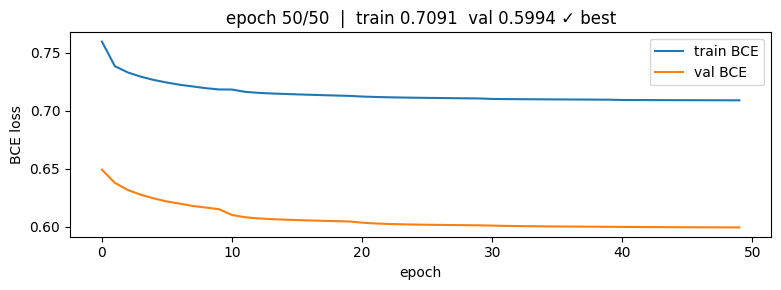

Training complete.


In [6]:
from functools import partial

import matplotlib.pyplot as plt
from IPython.display import clear_output
from tqdm.notebook import tqdm

from training.vertex_affordance_train import eval_vertex_bce, training_epoch_vertex_bce

for ep in range(start_epoch, N_EPOCHS):
    ep_label = f"epoch {ep+1}/{N_EPOCHS}"

    tr = training_epoch_vertex_bce(
        model, optimizer, ds_train,
        verb_embeddings=verb_embeddings,
        device=DEVICE,
        max_samples=MAX_SAMPLES,
        pos_weight=POS_WEIGHT,
        progress=partial(tqdm, desc=f"train {ep+1}", leave=False),
    )
    train_losses.append(tr)

    va = None
    if ds_val is not None:
        va = eval_vertex_bce(
            model, ds_val,
            verb_embeddings=verb_embeddings,
            device=DEVICE,
            max_samples=MAX_SAMPLES,
            pos_weight=POS_WEIGHT,
            progress=partial(tqdm, desc=f"val   {ep+1}", leave=False),
        )
        val_losses.append(va)

    scheduler.step()

    ckpt_data = {
        "epoch":          ep + 1,
        "model":          model.state_dict(),
        "optimizer":      optimizer.state_dict(),
        "scheduler":      scheduler.state_dict(),
        "train_losses":   train_losses,
        "val_losses":     val_losses,
        "best_val_loss":  best_val_loss,
        "model_cfg":      {"vlm_dim": model.cfg.vlm_dim, "verb_dim": model.cfg.verb_dim,
                           "sam3d_dim": model.cfg.sam3d_dim, "hidden_dims": list(model.cfg.hidden_dims),
                           "dropout": model.cfg.dropout},
    }
    torch.save(ckpt_data, CHECKPOINT_DIR / f"epoch_{ep+1:04d}.pt")

    is_best = va is not None and va < best_val_loss
    if is_best:
        best_val_loss = va
        torch.save(ckpt_data, CHECKPOINT_DIR / "best.pt")

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(train_losses, label="train BCE")
    if val_losses:
        ax.plot(val_losses, label="val BCE")
    ax.set_xlabel("epoch"); ax.set_ylabel("BCE loss"); ax.legend()
    ax.set_title(f"{ep_label}  |  train {tr:.4f}" + (f"  val {va:.4f}" + (" ✓ best" if is_best else "") if va is not None else ""))
    plt.tight_layout(); plt.show()

print("Training complete.")

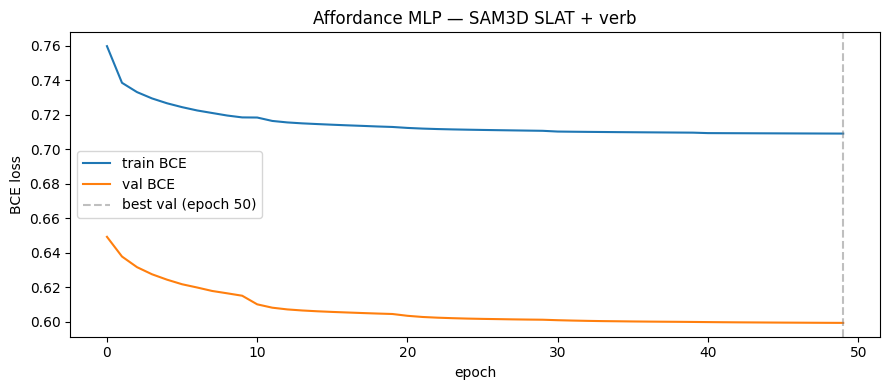

Checkpoints: /workspace/outputs/affordance_mlp
Best val loss: 0.5994 at epoch 50


In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label="train BCE")
if val_losses:
    ax.plot(val_losses, label="val BCE")
    best_ep = int(min(range(len(val_losses)), key=lambda i: val_losses[i]))
    ax.axvline(best_ep, color="gray", linestyle="--", alpha=0.5, label=f"best val (epoch {best_ep+1})")
ax.set_xlabel("epoch")
ax.set_ylabel("BCE loss")
ax.legend()
ax.set_title("Affordance MLP — SAM3D SLAT + verb")
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / "loss_curve.png", dpi=150)
plt.show()
print(f"Checkpoints: {CHECKPOINT_DIR}")
if val_losses:
    print(f"Best val loss: {min(val_losses):.4f} at epoch {best_ep+1}")